In [1]:
import pandas as pd
from sklearn.datasets import load_iris

In [2]:
data=load_iris()
dir(data)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [3]:
df=pd.DataFrame(data.data,columns=data.feature_names)
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [5]:
df['target']=data.target
df['flower_name']=df.target.apply(lambda x:data.target_names[x])
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,flower_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


In [6]:
x=df.drop(['target','flower_name'],axis='columns')
x

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [7]:
y=df.target
y

0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: target, Length: 150, dtype: int64

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sn

In [25]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2)
model=RandomForestClassifier(n_estimators=34)
model.fit(xtrain,ytrain)

RandomForestClassifier(n_estimators=34)

In [26]:
model.score(xtest,ytest)

1.0

In [28]:
ypred=model.predict(xtest)
cm=confusion_matrix(ytest,ypred)
cm

array([[ 7,  0,  0],
       [ 0, 10,  0],
       [ 0,  0, 13]])

Text(95.72222222222221, 0.5, 'actual')

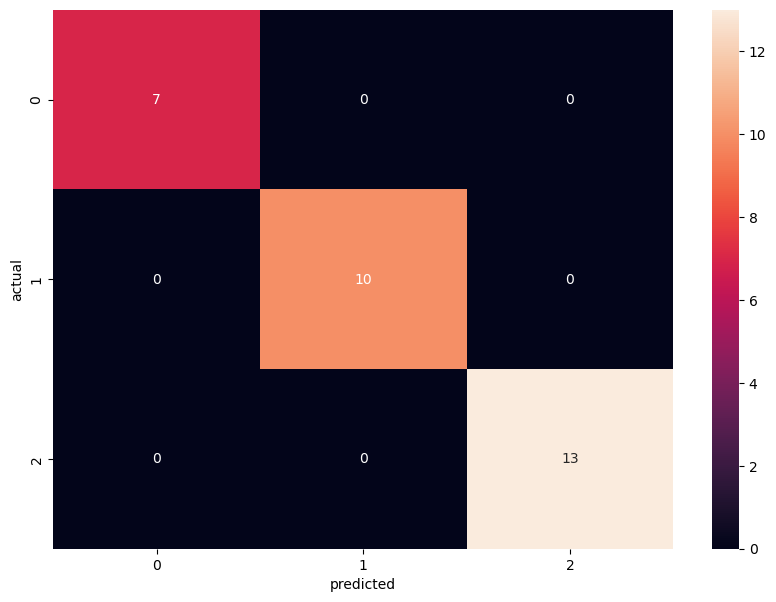

In [32]:
%matplotlib inline
plt.figure(figsize=(10,7))
sn.heatmap(cm,annot=True)
plt.xlabel('predicted')
plt.ylabel('actual')


In [48]:
#K Fold Validation
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier


In [62]:
cross_val_score(LogisticRegression(max_iter=200),data.data,data.target,cv=5)

array([0.96666667, 1.        , 0.93333333, 0.96666667, 1.        ])

In [63]:
cross_val_score(SVC(gamma='auto'),data.data,data.target,cv=5)

array([0.96666667, 1.        , 0.96666667, 0.96666667, 1.        ])

In [64]:
cross_val_score(RandomForestClassifier(n_estimators=5),data.data,data.target,cv=5)

array([0.96666667, 0.96666667, 0.93333333, 0.93333333, 1.        ])

In [65]:
cross_val_score(DecisionTreeClassifier(criterion='entropy'),data.data,data.target,cv=5)

array([0.96666667, 0.96666667, 0.9       , 0.93333333, 1.        ])